C:\Users\Administrator\AppData\Local\Temp\ipykernel_26600\3893151577.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


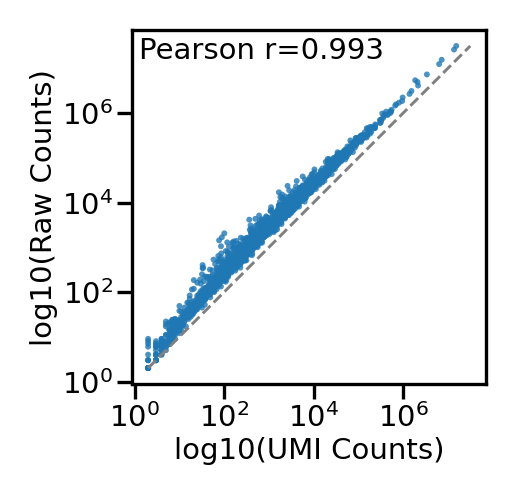

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.ticker as ticker

# 读取文件
data = pd.read_csv('data/seq_quant/probe_raw_counts.csv')  # 替换为实际路径

# 转换为log10
data['log_probe_u'] = np.log10(data['probe_u'] + 1)  # log10 of UMI counts
data['log_probe_f'] = np.log10(data['probe_f'] + 1)  # log10 of raw counts

# 计算Pearson相关性
r, _ = pearsonr(data['log_probe_u'], data['log_probe_f'])

# 设置figure和坐标轴大小（3 cm × 3 cm -> inch）
cm2in = 1 / 2.54
ax_w_in = 3.0 * cm2in
ax_h_in = 3.0 * cm2in

left_in   = 0.25
bottom_in = 0.25
right_in  = 0.25
top_in    = 0.15

fig_w = left_in + ax_w_in + right_in
fig_h = bottom_in + ax_h_in + top_in

# 创建figure
fig = plt.figure(figsize=(fig_w, fig_h), dpi=300, facecolor="none")

# 创建3cm x 3cm的轴
ax = fig.add_axes([
    left_in / fig_w,
    bottom_in / fig_h,
    ax_w_in / fig_w,
    ax_h_in / fig_h
])

# 绘制散点图
ax.scatter(data['log_probe_u'], data['log_probe_f'], s=2, alpha=0.8, edgecolors='none')


ax.text(
    0.02, 0.98,
    f"Pearson r={r:.3f}",
    transform=ax.transAxes,
    va='top', ha='left',
    fontsize=7,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0)
)

# 绘制y=x线（参考线）
mn = min(data['log_probe_u'].min(), data['log_probe_f'].min())
mx = max(data['log_probe_u'].max(), data['log_probe_f'].max())
ax.plot([mn, mx], [mn, mx], color='gray', lw=0.7, ls='--')

# 设置坐标轴标签
ax.set_xlabel("log10(UMI Counts)", fontsize=7,labelpad=1)
ax.set_ylabel("log10(Raw Counts)", fontsize=7,labelpad=1)


# 设置坐标轴比例一致
ax.set_aspect('equal', adjustable='box')

# 将坐标轴格式化为指数形式（10^x）
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'$10^{{{x:.0f}}}$'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'$10^{{{x:.0f}}}$'))

# 设置字体大小
ax.tick_params(axis='x', labelsize=7, pad=1)  # X轴刻度标签距离坐标轴的距离
ax.tick_params(axis='y', labelsize=7, pad=1)  # Y轴刻度标签距离坐标轴的距离


# 保存图像，透明背景
plt.tight_layout()
plt.savefig('data/seq_quant/scatter_probe_correlation.png', dpi=300, bbox_inches="tight", pad_inches=0, transparent=True)
plt.savefig('data/seq_quant/scatter_probe_correlation.pdf',
            bbox_inches="tight", pad_inches=0, transparent=True)
plt.show()


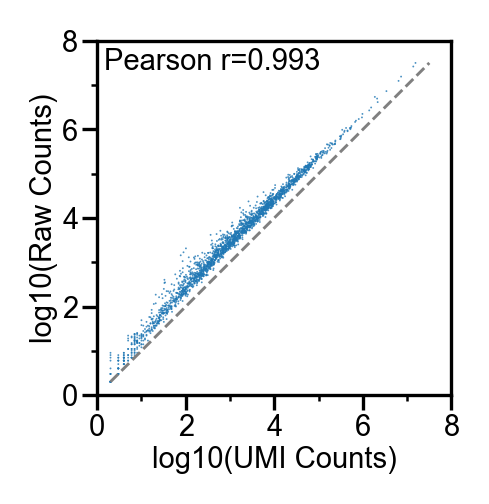

In [4]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.ticker as ticker

# ------- 关键：嵌入 TrueType 字体，避免 Type3 -------
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "text.usetex": False,          # 确保不走 TeX
})

# 读取文件
data = pd.read_csv('data/seq_quant/probe_raw_counts.csv')  # 替换为实际路径

# 转换为log10
data['log_probe_u'] = np.log10(data['probe_u'] + 1)  # log10 of UMI counts
data['log_probe_f'] = np.log10(data['probe_f'] + 1)  # log10 of raw counts

# 计算Pearson相关性
r, _ = pearsonr(data['log_probe_u'], data['log_probe_f'])

# ---- 固定轴尺寸：3.3cm × 3.3cm ----
cm2in = 1 / 2.54
ax_w_in = 3.0 * cm2in
ax_h_in = 3.0 * cm2in
left_in, bottom_in, right_in, top_in = 0.25, 0.25, 0.25, 0.15
fig_w = left_in + ax_w_in + right_in
fig_h = bottom_in + ax_h_in + top_in

fig = plt.figure(figsize=(fig_w, fig_h), dpi=300, facecolor="none")
ax = fig.add_axes([
    left_in / fig_w,
    bottom_in / fig_h,
    ax_w_in / fig_w,
    ax_h_in / fig_h
])

# 散点
ax.scatter(data['log_probe_u'], data['log_probe_f'], s=0.2, alpha=0.8, edgecolors='none')

ax.text(
    0.02, 0.98,
    f"Pearson r={r:.3f}",
    transform=ax.transAxes,
    va='top', ha='left',
    fontsize=7,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0)
)

# y=x 参考线
mn = min(data['log_probe_u'].min(), data['log_probe_f'].min())
mx = max(data['log_probe_u'].max(), data['log_probe_f'].max())
ax.plot([mn, mx], [mn, mx], color='gray', lw=0.7, ls='--')

ax.set_xlabel("log10(UMI Counts)", fontsize=7, labelpad=1)
ax.set_ylabel("log10(Raw Counts)", fontsize=7, labelpad=1)
ax.set_aspect('equal', adjustable='box')
import matplotlib.ticker as ticker
import numpy as np

# --- Unicode 上标（避免 MathText，不用 $...$）---
_sup = str.maketrans("0123456789-+", "⁰¹²³⁴⁵⁶⁷⁸⁹⁻⁺")
def fmt_10pow(x, _pos=None):
    k = int(np.round(x))
    return "10" + str(k).translate(_sup)

# （可选）先把轴范围设成整数 log10 边界，刻度更干净
xmin = np.floor(min(data['log_probe_u'].min(), data['log_probe_f'].min()))
xmax = np.ceil (max(data['log_probe_u'].max(), data['log_probe_f'].max()))
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)

# --- 主刻度：每 2（=每 10^2）---
# ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
# ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_10pow))
# ax.yaxis.set_major_formatter(ticker.FuncFormatter(fmt_10pow))

ax.set_xlim(0, 8)
ax.set_ylim(0, 8)

# （可选）次刻度：每 1（=每 10^1）不标数字，只做小刻度线
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.tick_params(which="minor", length=1.5)


ax.tick_params(axis='x', labelsize=7, pad=1)
ax.tick_params(axis='y', labelsize=7, pad=1)

# 保存：不要 tight_layout + tight bbox（避免尺寸被裁）
fig.savefig('data/seq_quant/scatter_probe_correlation.pdf', dpi=300, bbox_inches=None, pad_inches=0, transparent=True)
fig.savefig('data/seq_quant/scatter_probe_correlation.png', dpi=300, bbox_inches=None, pad_inches=0, transparent=True)
plt.show()
plt.close(fig)


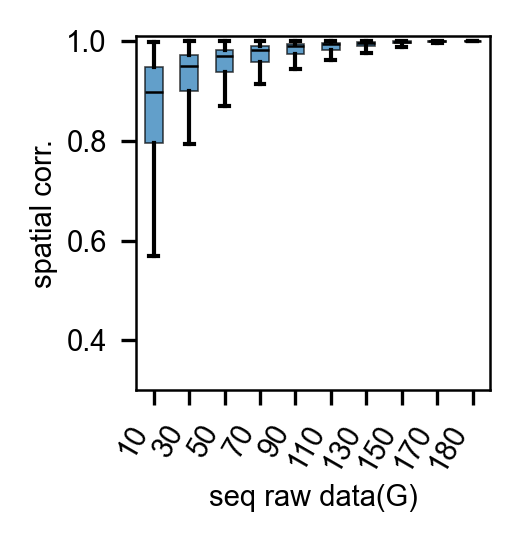

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

df = pd.read_csv("data/seq_quant/full_quant_info.csv")

# 原来所有的 downsample 列
all_cols = df.columns[1:]   # 跳过 gene 那一列

# 每 3 列取 1 列
step = 2
value_cols = list(all_cols[::step])

# 可选：保证最后一列也画上（比如 180）
if all_cols[-1] not in value_cols:
    value_cols.append(all_cols[-1])

# 可选裁剪，防止一两个很低的拉坏图
CLIP_LOW = 0.3
data_for_box = []
for c in value_cols:
    v = df[c].dropna().values
    v = np.clip(v, CLIP_LOW, 1.0)
    data_for_box.append(v)

# -------- 下面跟之前一样：3cm × 3cm --------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
})

cm2in = 1/2.54
ax_w_in = 3.0*cm2in
ax_h_in = 3.0*cm2in
left_in, bottom_in, right_in, top_in = 0.35, 0.35, 0.25, 0.15
fig_w = left_in + ax_w_in + right_in
fig_h = bottom_in + ax_h_in + top_in

fig = plt.figure(figsize=(fig_w, fig_h), dpi=300, facecolor="none")
ax = fig.add_axes([
    left_in/fig_w,
    bottom_in/fig_h,
    ax_w_in/fig_w,
    ax_h_in/fig_h
])

bp = ax.boxplot(
    data_for_box,
    showfliers=False,
    patch_artist=True
)

for box in bp['boxes']:
    box.set( alpha=0.7) # facecolor="#D55E00",
    box.set(linewidth=0.4)
for median in bp['medians']:
    median.set(color="black", linewidth=0.6)

ax.set_xticks(range(1, len(value_cols)+1))
ax.set_xticklabels(value_cols, rotation=60, ha="right")
ax.set_xlabel("seq raw data(G)", fontsize=7, labelpad=2)
ax.set_ylabel("spatial corr.", fontsize=7, labelpad=2)
ax.set_ylim(CLIP_LOW, 1.01)
for sp in ax.spines.values():
    sp.set_linewidth(0.6)

out_dir = Path("data/seq_quant"); out_dir.mkdir(parents=True, exist_ok=True)
stem = out_dir / "spatial_corr_box_3x3cm_step3"
fig.savefig(stem.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.03, transparent=True)
fig.savefig(stem.with_suffix(".pdf"),              bbox_inches="tight", pad_inches=0.03, transparent=True)
fig.savefig(stem.with_suffix(".svg"),              bbox_inches="tight", pad_inches=0.03)


In [2]:
# =========================
# Summarize & export the plotted data (CLIPPED)
# =========================
summary = []
for col, v in zip(value_cols, data_for_box):
    v = np.asarray(v, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        summary.append({"col": col, "n": 0})
        continue
    summary.append({
        "col": col,
        "n": int(v.size),
        "mean": float(np.mean(v)),
        "std": float(np.std(v, ddof=1)) if v.size > 1 else np.nan,
        "median": float(np.median(v)),
        "q25": float(np.percentile(v, 25)),
        "q75": float(np.percentile(v, 75)),
        "min": float(np.min(v)),
        "max": float(np.max(v)),
    })

df_summary = pd.DataFrame(summary)

# 输出到文件
summary_csv  = out_dir / "spatial_corr_box_data_summary_CLIPPED.csv"
summary_xlsx = out_dir / "spatial_corr_box_data_summary_CLIPPED.xlsx"
df_summary.to_csv(summary_csv, index=False)
df_summary.to_excel(summary_xlsx, index=False)

# notebook中展示
print("\n=== Boxplot data summary (CLIPPED) ===")
print(df_summary.to_string(index=False))

# 如果你在 Jupyter，想用更漂亮的表格显示：
try:
    from IPython.display import display
    display(df_summary)
except Exception:
    pass

print(f"\nSaved:\n  {summary_csv}\n  {summary_xlsx}")



=== Boxplot data summary (CLIPPED) ===
col   n     mean          std   median      q25      q75      min      max
 10 731 0.834979 1.675200e-01 0.898250 0.795653 0.946824 0.300000 0.997266
 30 731 0.905527 1.166324e-01 0.950709 0.899667 0.971684 0.300000 1.000000
 50 731 0.936146 9.097997e-02 0.970486 0.937177 0.982341 0.300000 1.000000
 70 731 0.955432 7.423836e-02 0.981824 0.958321 0.989319 0.300000 1.000000
 90 731 0.970152 5.411887e-02 0.988999 0.973260 0.993875 0.300000 1.000000
110 731 0.979998 4.177855e-02 0.993696 0.982696 0.996693 0.300000 1.000000
130 731 0.987255 3.483053e-02 0.996519 0.989675 0.998381 0.300000 1.000000
150 731 0.993050 1.784955e-02 0.998485 0.995071 0.999383 0.705761 1.000000
170 731 0.997792 9.771297e-03 0.999659 0.998669 0.999897 0.814937 1.000000
180 731 1.000000 6.610959e-16 1.000000 1.000000 1.000000 1.000000 1.000000


,col,n,mean,std,median,q25,q75,min,max
0,10,731,0.834979,1.675200e-01,0.898250,0.795653,0.946824,0.300000,0.997266
1,30,731,0.905527,1.166324e-01,0.950709,0.899667,0.971684,0.300000,1.000000
2,50,731,0.936146,9.097997e-02,0.970486,0.937177,0.982341,0.300000,1.000000
3,70,731,0.955432,7.423836e-02,0.981824,0.958321,0.989319,0.300000,1.000000
4,90,731,0.970152,5.411887e-02,0.988999,0.973260,0.993875,0.300000,1.000000
5,110,731,0.979998,4.177855e-02,0.993696,0.982696,0.996693,0.300000,1.000000
6,130,731,0.987255,3.483053e-02,0.996519,0.989675,0.998381,0.300000,1.000000
7,150,731,0.993050,1.784955e-02,0.998485,0.995071,0.999383,0.705761,1.000000
8,170,731,0.997792,9.771297e-03,0.999659,0.998669,0.999897,0.814937,1.000000
9,180,731,1.000000,6.610959e-16,1.000000,1.000000,1.000000,1.000000,1.000000



Saved:
  data\seq_quant\spatial_corr_box_data_summary_CLIPPED.csv
  data\seq_quant\spatial_corr_box_data_summary_CLIPPED.xlsx
